Linear Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('new_insurance_data.csv')

In [5]:
df.head(5)

,age,gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [4]:
df.tail()

,age,gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,170380500.5,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,201515184.8,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,223644981.3,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,252892382.6,3.0,4.006359e+09,southeast,62592.87309
1337,54.0,female,47.410,0.0,yes,63982.80926,31.0,1100328.0,261631699.3,3.0,4.117197e+09,southeast,63770.42801


In [5]:
df.sample(5)

,age,gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
835,58.0,female,39.050,0.0,no,30333.000330,21.0,935611.0,3445156.043,1.0,1.422656e+08,southeast,11856.41150
657,41.0,male,29.640,5.0,no,10176.262270,8.0,903821.0,7225558.331,1.0,9.606326e+07,northeast,9222.40260
49,18.0,male,22.990,0.0,no,44557.441430,20.0,748257.0,2617335.712,0.0,6.447311e+07,northeast,1704.56810
320,32.0,female,29.590,1.0,no,4414.416523,9.0,835450.0,1444796.219,1.0,2.527777e+07,southeast,4562.84210
634,46.0,female,33.725,1.0,no,16550.036130,5.0,895133.0,9304818.572,1.0,1.398843e+08,northeast,8823.98575


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   gender                           1338 non-null   str    
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   str    
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   str    
 12  charges                        

In [7]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [8]:
df.describe(include='O')

C:\Users\khush\AppData\Local\Temp\ipykernel_32996\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,gender,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [9]:
# nunique()  unique()  value_counts()

In [10]:
df['gender'].value_counts()

gender
male      676
female    662
Name: count, dtype: int64

In [11]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [20]:
# Data Cleaning

# Null Values
# Duplicated
# Outliers

df.isnull().sum()

age                                 3
gender                              0
bmi                                 0
children                            5
smoker                              0
Claim_Amount                       11
past_consultations                  0
num_of_steps                        1
Hospital_expenditure                0
NUmber_of_past_hospitalizations     0
Anual_Salary                        0
region                              0
charges                             0
dtype: int64

In [13]:
df.shape

(1338, 13)

In [21]:
df=df.dropna()

In [22]:
df.isnull().sum()

age                                0
gender                             0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [ ]:
#df["region"]=df["region"].dropna()

In [ ]:
df.duplicated().sum()
# df.drop_duplicates(keep="First") # keep='last" keep="None"

np.int64(0)

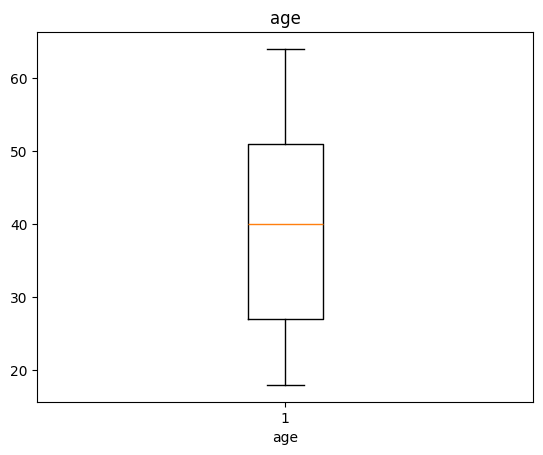

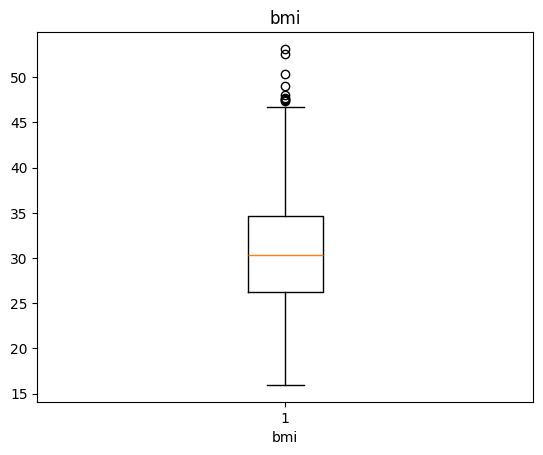

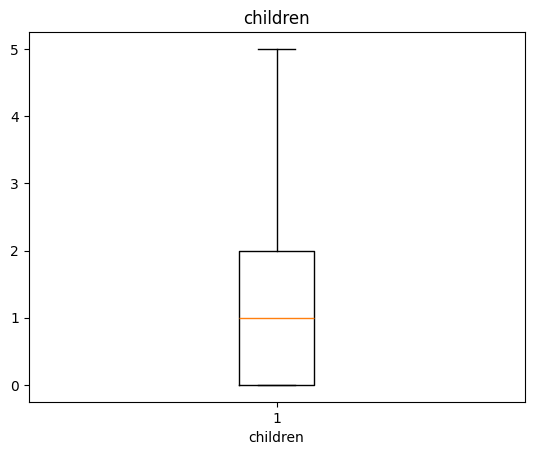

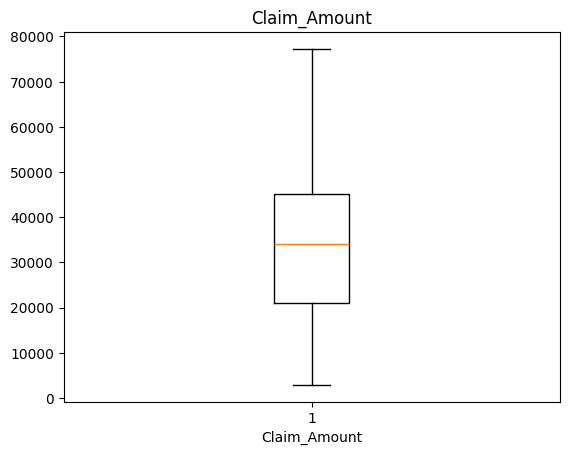

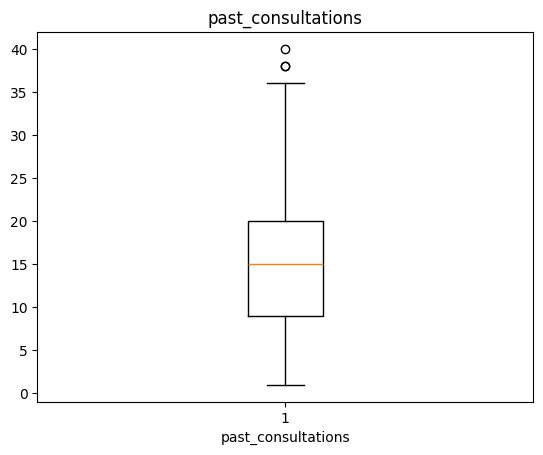

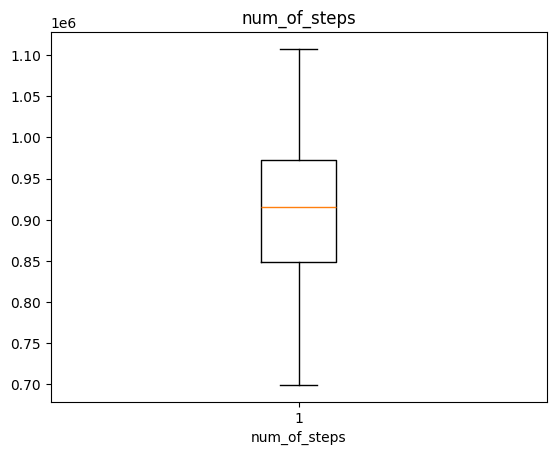

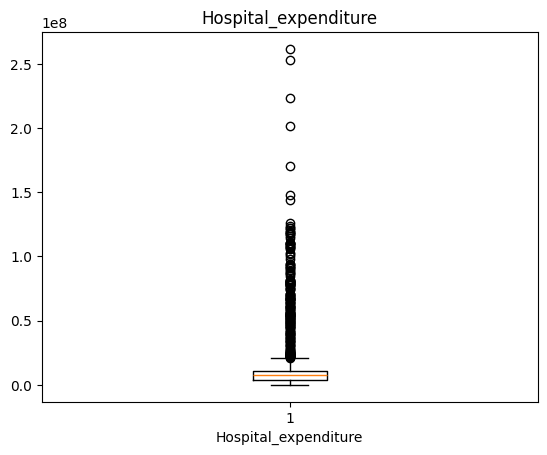

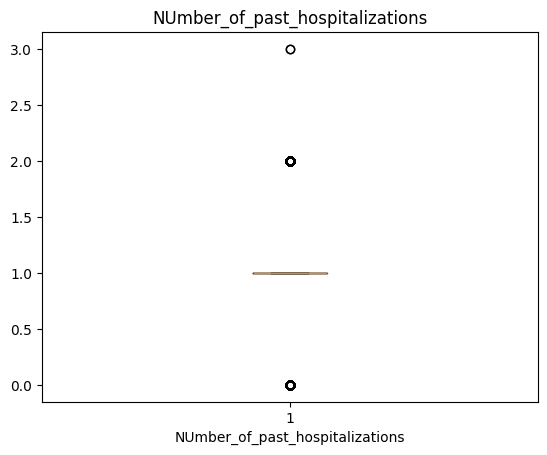

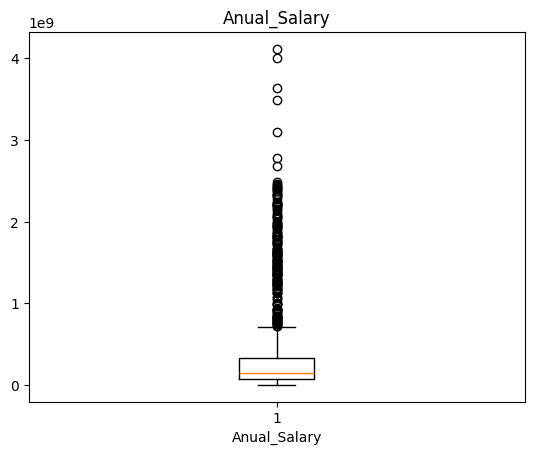

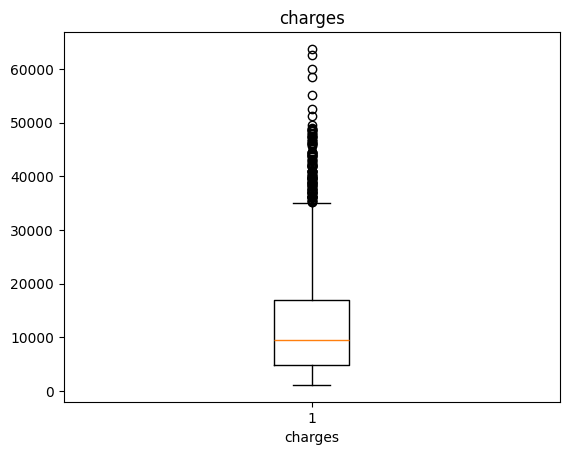

In [ ]:
import matplotlib.pyplot as plt

for col in df.columns:
    if df[col].dtype == "float64":     #df[i].dtypes=="int64" or df[i].dtypes=="float64"
        try:
            plt.boxplot(df[col].dropna())
            plt.title(col)
            plt.xlabel(col)
            plt.show()
        except Exception as e:
            print(f"Error in column: {col}")
            print(e)

In [7]:
Q1=df.bmi.quantile(0.25)
Q3=df.bmi.quantile(0.75)
IQR=Q3-Q1
LL=Q1-1.5*IQR
UL=Q3+1.5*IQR

df=df[(df["bmi"]>=LL)&(df["bmi"]<=UL)]

In [8]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='str')

In [9]:
Q1=df.past_consultations.quantile(0.25)
Q3=df.past_consultations.quantile(0.75)
IQR=Q3-Q1
LL=Q1-1.5*IQR
UL=Q3+1.5*IQR

df=df[(df.past_consultations>=LL)&(df.past_consultations<=UL)]

In [11]:
Q1=df.Hospital_expenditure.quantile(0.25)
Q3=df.Hospital_expenditure.quantile(0.75)
IQR=Q3-Q1
LL=Q1-1.5*IQR
UL=Q3+1.5*IQR

df=df[(df["Hospital_expenditure"]>=LL)&(df["Hospital_expenditure"]<=UL)]

In [12]:
Q1=df.Anual_Salary.quantile(0.25)
Q3=df.Anual_Salary.quantile(0.75)
IQR=Q3-Q1
LL=Q1-1.5*IQR
UL=Q3+1.5*IQR

df=df[(df["Anual_Salary"]>=LL)&(df["Anual_Salary"]<=UL)]

In [13]:
Q1=df.NUmber_of_past_hospitalizations.quantile(0.25)
Q3=df.NUmber_of_past_hospitalizations.quantile(0.75)
IQR=Q3-Q1
LL=Q1-1.5*IQR
UL=Q3+1.5*IQR

df=df[(df["NUmber_of_past_hospitalizations"]>=LL)&(df["NUmber_of_past_hospitalizations"]<=UL)]

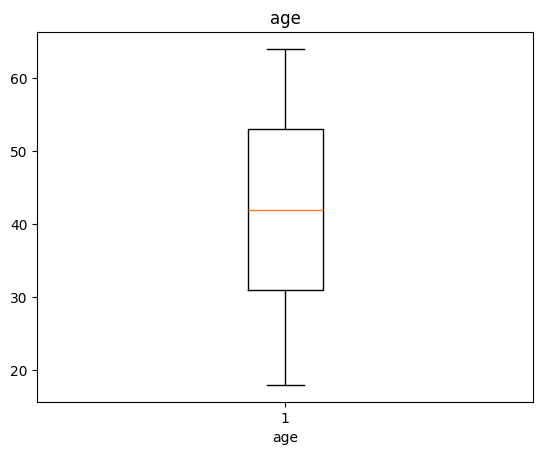

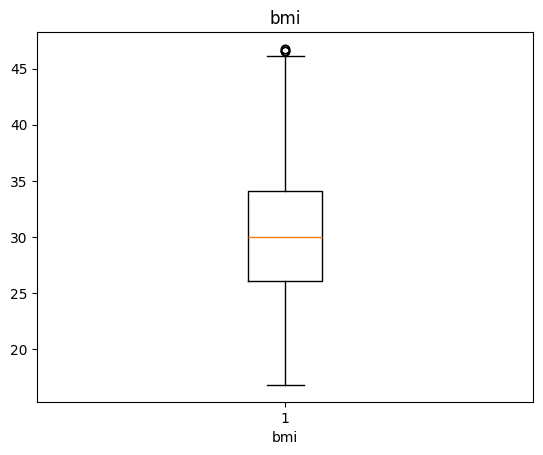

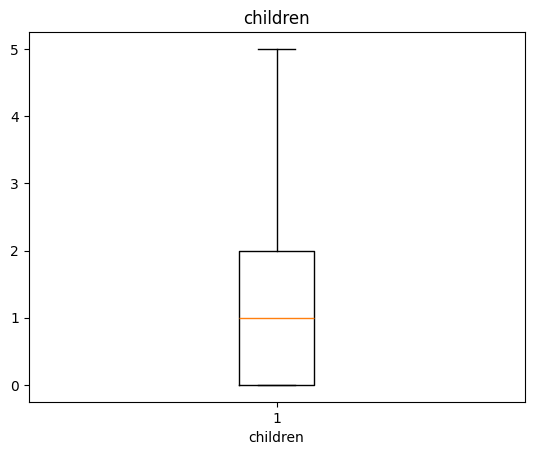

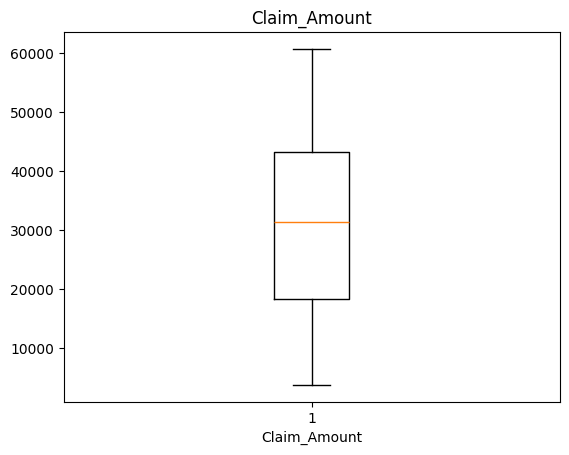

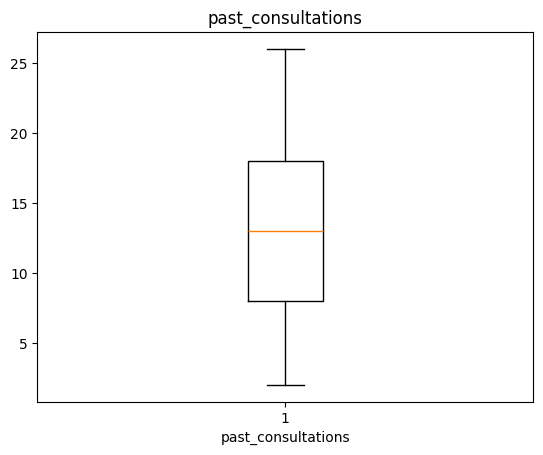

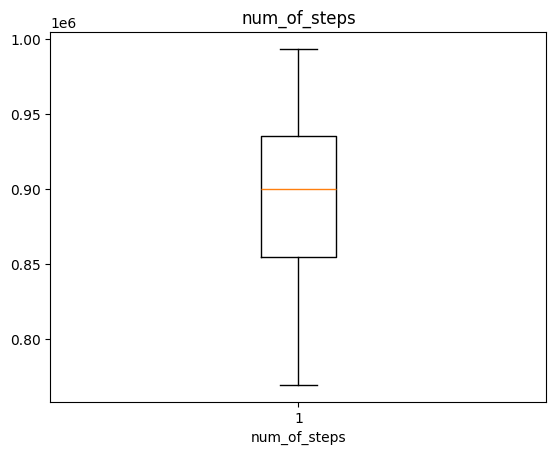

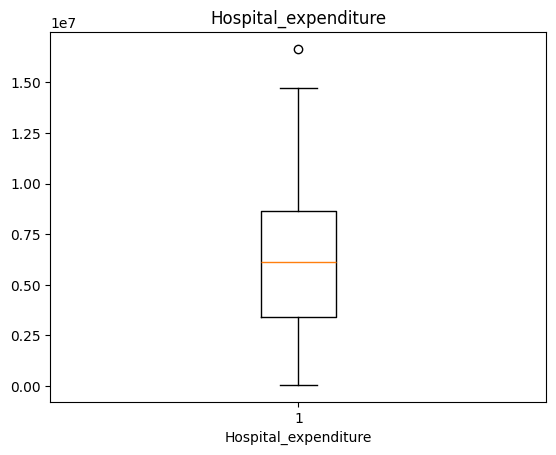

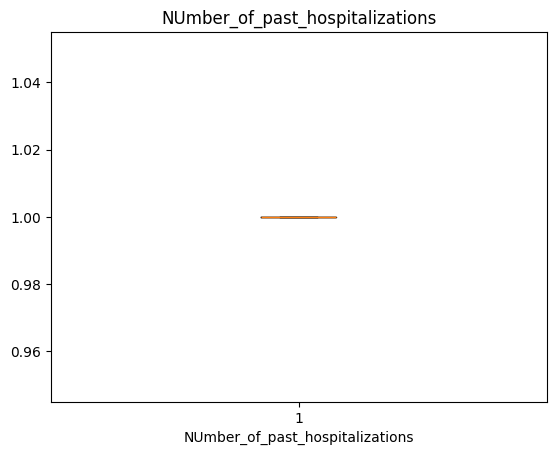

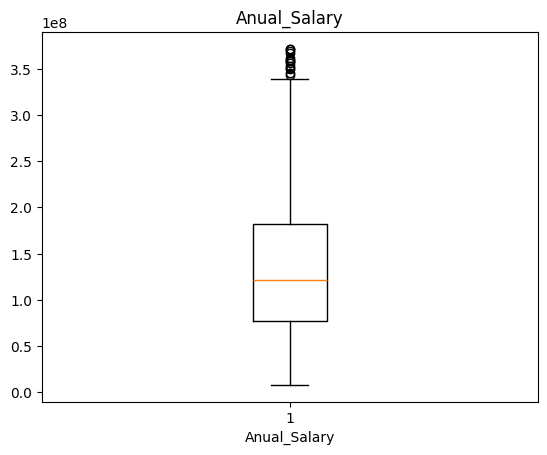

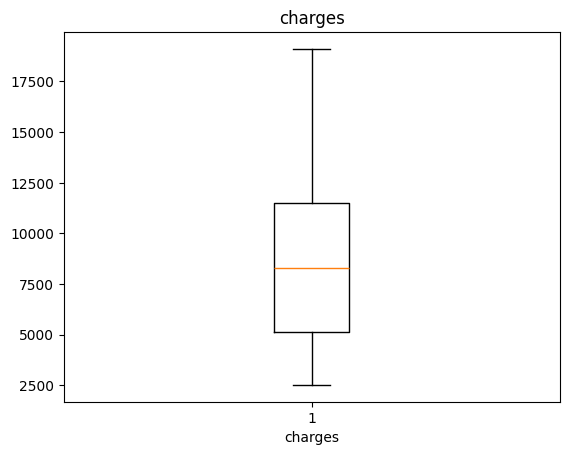

In [14]:
for col in df.columns:
    if df[col].dtype == "float64":     #df[i].dtypes=="int64" or df[i].dtypes=="float64"
        try:
            plt.boxplot(df[col].dropna())
            plt.title(col)
            plt.xlabel(col)
            plt.show()
        except Exception as e:
            print(f"Error in column: {col}")
            print(e)

Feature Selection for the Regression

In [1]:
# Feature selection - selecting the right columns to be taken for independent feature
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [23]:

X=df.loc[ : , [ 'age',
 'bmi',
 'children',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',                # all columns except for object type data
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary',]]             # All remaining columns - Independent columns

y=df.loc[:,'charges']  # charger - Dependent or Target column

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.80,random_state=0)

In [25]:
X_train.shape

(675, 9)

In [26]:
y_train.shape

(675,)

In [27]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[0.,0.,0.,...,0.,0.,0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['age','bmi','children',...,'Hospital_expenditure', 'NUmber_of_past_hospitalizations','Anual_Salary']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.946e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [28]:
predict=model.predict(X_test)

In [29]:
result=pd.DataFrame(columns=["Actual values" ,"Predicted values"])

result["Actual values"] =y_test
result["Predicted values"]=predict

In [30]:
from sklearn.metrics import *

In [31]:
r2_score(y_test,predict)*100

96.01391917296242

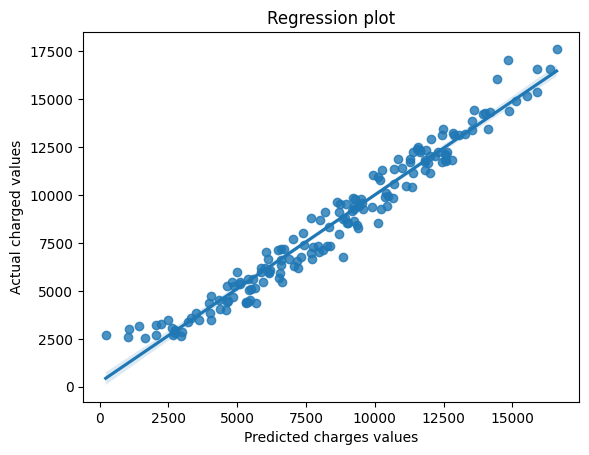

In [35]:
sns.regplot(x=predict , y=y_test)
plt.xlabel("Predicted charges values")
plt.ylabel("Actual charged values")
plt.title("Regression plot")
plt.savefig("Linear_Regression_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# One-Hot Encoding for categorical columns
df_encoded = pd.get_dummies(df, columns=["gender", "smoker", "region"], drop_first=True)
df_encoded.head()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
151,25.0,27.550,0.0,39148.95495,10.0,780652.0,8.614147e+06,1.0,54526009.33,2523.16950,True,False,True,False,False
152,22.0,20.235,0.0,41547.52536,13.0,802627.0,2.491594e+05,1.0,16718473.13,2527.81865,False,False,True,False,False
153,25.0,35.625,0.0,39660.60193,12.0,770773.0,3.043323e+06,1.0,48526941.68,2534.39375,True,False,True,False,False
154,20.0,31.130,2.0,16032.87148,7.0,769255.0,1.599069e+06,1.0,24412621.85,2566.47070,True,False,False,True,False
155,21.0,17.400,1.0,31090.98977,21.0,778769.0,3.015365e+06,1.0,58535788.80,2585.26900,False,False,False,False,True


In [37]:
#Feature Selection for categorical data
X = df_encoded.drop("charges", axis=1)   # Independent variables
y = df_encoded["charges"]                # Dependent variable

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.80,
    random_state=0
)

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0., 0., 0.,...,-0.,-0., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.946e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [40]:
predict = model.predict(X_test)

In [41]:
result = pd.DataFrame({
    "Actual Values": y_test,
    "Predicted Values": predict
})

result.head()

,Actual Values,Predicted Values
913,13204.28565,13285.972539
968,14426.07385,13594.037596
827,11763.00090,12598.998683
501,6986.69700,7688.136851
853,12129.61415,12547.195871


In [42]:
print("R2 Score :", r2_score(y_test, predict))
print("R2 Score (%) :", r2_score(y_test, predict) * 100)

print("MAE :", mean_absolute_error(y_test, predict))
print("MSE :", mean_squared_error(y_test, predict))
print("RMSE :", np.sqrt(mean_squared_error(y_test, predict)))

R2 Score : 0.9601391917291534
R2 Score (%) : 96.01391917291534
MAE : 593.2712876876433
MSE : 547756.6110239009
RMSE : 740.1058106945932


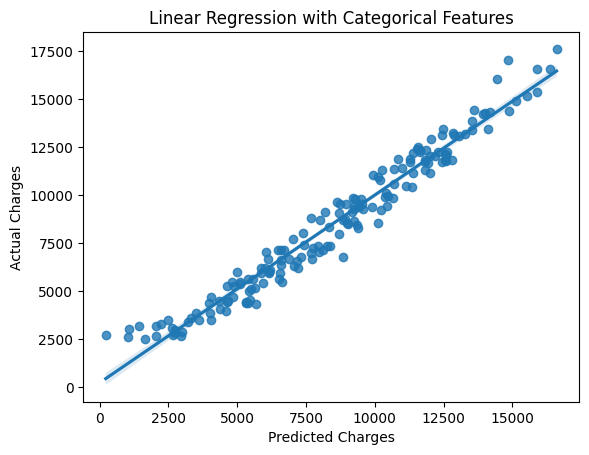

<Figure size 600x300 with 0 Axes>

In [49]:
sns.regplot(x=predict, y=y_test)

plt.xlabel("Predicted Charges")
plt.ylabel("Actual Charges")
plt.title("Linear Regression with Categorical Features")

plt.figure(figsize=(6,3))
plt.savefig("Linear_Regression_Plot_2.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
plt.subplot(1,2,1)
plt.box(df["age"])
plt.subplot(1,2,2)
plt.box(["bmi"])


Logistic Regression

In [ ]:
# Convert 'charges' into binary classes
# 0 = Below Median, 1 = Above Median

df["target"] = (df["charges"] > df["charges"].median()).astype(int)

In [ ]:
X = df.drop(["charges", "target"], axis=1)
y = df["target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()